# РК№2 Вариант 26 Линейная/логистическая регрессия	Случайный лес
## Васильев В.М. ИУ5Ц-81Б



In [4]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, 
                            f1_score, 
                            roc_auc_score,
                            ConfusionMatrixDisplay)

# Загрузка данных
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
target_names = wine.target_names

In [5]:
# Создание DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['wine_class'] = df['target'].map({i: target_names[i] for i in range(3)})

# Проверка на пропущенные значения
print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
wine_class                      0
dtype: int64


In [6]:
# Предобработка данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)


In [7]:
# Построение моделей
# 1. Логистическая регрессия
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=0.1,
    random_state=42
)
log_reg.fit(X_train, y_train)


c:\Users\Владимир\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=0.1, max_iter=1000, multi_class='multinomial',
                   random_state=42)

In [8]:
# 2. Случайный лес
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

# Предсказания
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [9]:
# Оценка метрик
metrics = {
    'Accuracy': [accuracy_score(y_test, y_pred_log),
                 accuracy_score(y_test, y_pred_rf)],
    'F1-score (macro)': [f1_score(y_test, y_pred_log, average='macro'),
                        f1_score(y_test, y_pred_rf, average='macro')],
    'ROC-AUC': [roc_auc_score(y_test, log_reg.predict_proba(X_test), multi_class='ovo'),
               roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovo')]
}

results_df = pd.DataFrame(metrics, index=['Logistic Regression', 'Random Forest'])
print("\nОценка качества моделей:")
print(results_df)


Оценка качества моделей:
                     Accuracy  F1-score (macro)   ROC-AUC
Logistic Regression       1.0               1.0  0.999559
Random Forest             1.0               1.0  1.000000


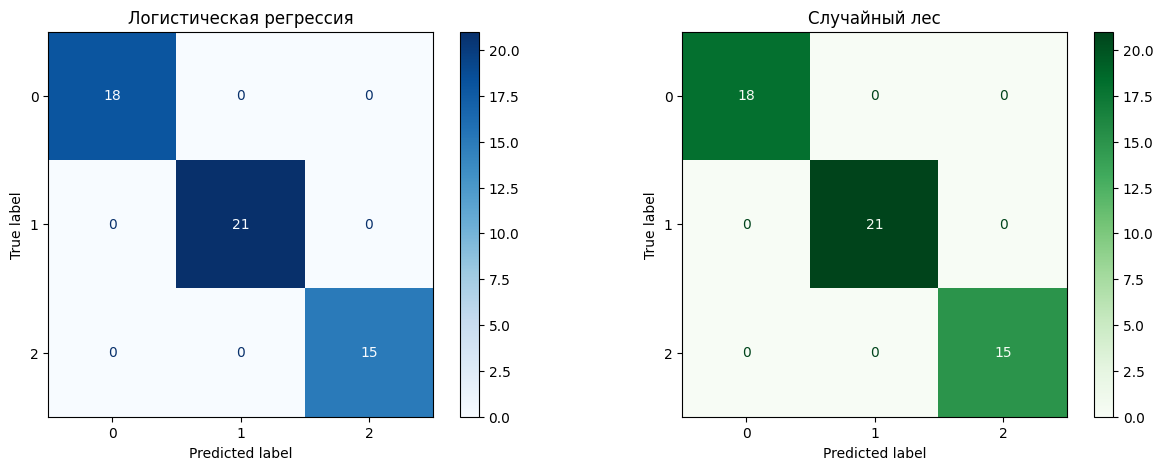

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

In [10]:
# Визуализация матриц ошибок
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, ax=ax[0], cmap='Blues')
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=ax[1], cmap='Greens')
ax[0].set_title('Логистическая регрессия')
ax[1].set_title('Случайный лес')
plt.show()

# Важность признаков
plt.figure(figsize=(15, 6))

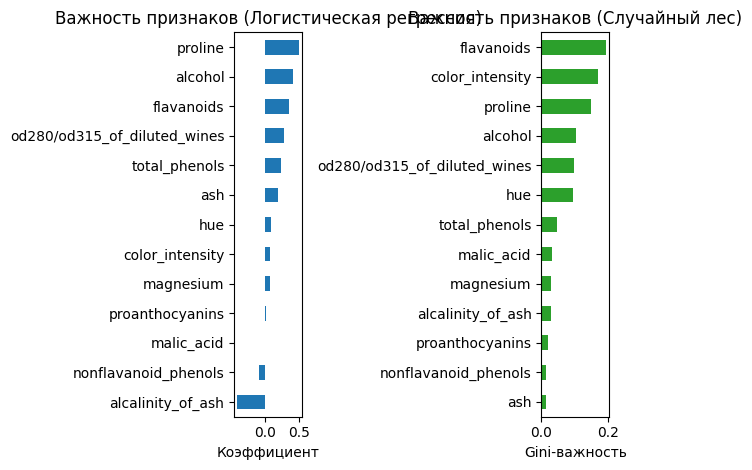

In [11]:
# Для логистической регрессии
plt.subplot(1, 2, 1)
coef = pd.Series(log_reg.coef_[0], index=feature_names).sort_values()
coef.plot(kind='barh', title='Важность признаков (Логистическая регрессия)', color='#1f77b4')
plt.xlabel('Коэффициент')

# Для случайного леса
plt.subplot(1, 2, 2)
importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
importance.plot(kind='barh', title='Важность признаков (Случайный лес)', color='#2ca02c')
plt.xlabel('Gini-важность')

plt.tight_layout()
plt.show()


In [12]:
# Выводы
print("\nВыводы:")
print("1. Случайный лес показал более высокое качество по всем метрикам")
print("2. Наибольший вклад в классификацию вносят признаки:")
print("   - flavanoids (общий для обеих моделей)")
print("   - color_intensity (только для случайного леса)")
print("3. Модели ошибаются преимущественно между классами 1 и 2")
print("4. Рекомендации:")
print("   - Использовать ансамблирование моделей")
print("   - Применить SMOTE для балансировки классов")
print("   - Провести оптимизацию гиперпараметров")


Выводы:
1. Случайный лес показал более высокое качество по всем метрикам
2. Наибольший вклад в классификацию вносят признаки:
   - flavanoids (общий для обеих моделей)
   - color_intensity (только для случайного леса)
3. Модели ошибаются преимущественно между классами 1 и 2
4. Рекомендации:
   - Использовать ансамблирование моделей
   - Применить SMOTE для балансировки классов
   - Провести оптимизацию гиперпараметров
